# Deprecated API usage in LLM code completion

Reproduction of the baseline evaluation from Wang et al., *LLMs Meet
Library Evolution* (ICSE 2025): does an LLM's code completion use a
deprecated library API or its replacement?

Runs **both** DeepSeek-Coder-1.3b-instruct (local, GPU recommended:
**Runtime -> Change runtime type -> T4 GPU**) and Gemini (API) in one pass
over a split of the paper's benchmark, and reports **AUP** (API Usage
Plausibility) and **DUR** (Deprecated Usage Rate) for each, plus a
**HumanEval pass@1** control set, a per-library breakdown, and a token/cost
table. Runs are **checkpointed** to disk and resume automatically if
interrupted.

**Before running:** upload these four files next to this notebook (drag
into Colab's file browser, or use the upload prompt in section 3 below):
- `mappings.json`
- `sample.json`
- `smoke.json`
- `humaneval.json`

A fifth file, `sample_full.json` (~27,427 prompts, ~158 MB), is only
needed if you set `SPLIT = "full"` in section 2 -- built from the raw
figshare dataset by `scripts/build_sample_full.py` (not part of this
notebook; run it once locally, then upload the file it produces). Skip it
entirely for `smoke`/`sample` runs.

All code is in this one notebook; only the data is a separate upload.


## 1. Install dependencies

Colab already ships a CUDA `torch`; this adds what's missing.

In [ ]:
!pip install -q transformers accelerate google-genai


## 2. Configuration

`RUNS` lists every (model, mode) combination to run in this pass -- edit
it to add/remove combinations. `deepseek` supports `raw` and `chat`;
`gemini` supports `chat` only. The first entry in `RUNS` is treated as the
baseline for the cost-comparison table in section 12.


In [ ]:
SPLIT = "smoke"      # "smoke" (32 prompts, quick check), "sample" (2,101 prompts),
                       # or "full" (all ~27,427 prompts -- needs sample_full.json
                       # uploaded, see section 1's intro; expect hours, not minutes)
LIMIT = 0            # max prompts per (library, category); 0 = no cap
SAMPLE_SEED = 42      # shuffle seed used only when LIMIT > 0, so capping doesn't
                       # always take the same first N of whatever order the file is in

HUMANEVAL_LIMIT = 20  # max HumanEval problems to run; 0 = all 164

RUNS = [
    ("deepseek", "raw"),
    ("deepseek", "chat"),
    ("gemini", "chat"),
]

# Where result JSONL files are written and read from for resuming, one
# subfolder per method (e.g. RESULTS_DIR/baseline/results_deepseek_raw.jsonl).
# Defaults to ./output, which is enough to resume after an in-session error.
# For a run that must survive a Colab disconnect, mount Drive first
# (from google.colab import drive; drive.mount("/content/drive")) and point
# this at a folder under it instead, e.g. "/content/drive/MyDrive/depapi_output" --
# strongly recommended for SPLIT = "full", which will span multiple sessions.
RESULTS_DIR = "output"

GEMINI_PACING_SECS = 1.0  # fixed delay after every successful Gemini call, to
                            # stay clear of free-tier per-minute rate limits

import os
os.environ["GEMINI_API_KEY"] = "AQ.Ab8RN6KN2lVlKPLRwLH6regwjgLDh8vj-iVYxvVjlo9wAhC9Yg"   # uncomment and fill in to include gemini runs


## 3. Load data (uploaded, not embedded)

Expects `mappings.json`, `sample.json`, `smoke.json`, `humaneval.json` in
the current directory. If any are missing and this is running on Colab,
opens the upload dialog for you to pick them. `sample_full.json` is only
checked for, and only prompted for, when `SPLIT == "full"`.


In [ ]:
import json, os

REQUIRED = ["mappings.json", "sample.json", "smoke.json", "humaneval.json"]
if SPLIT == "full":
    REQUIRED = REQUIRED + ["sample_full.json"]

missing = [f for f in REQUIRED if not os.path.exists(f)]
if missing:
    print(f"missing {missing} -- please select them in the upload dialog")
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        pass
    missing = [f for f in REQUIRED if not os.path.exists(f)]
    if missing:
        raise FileNotFoundError(
            f"still missing {missing} -- place these files next to the notebook and re-run this cell"
        )

MAPPINGS = json.load(open("mappings.json", encoding="utf-8"))
SAMPLE = json.load(open("sample.json", encoding="utf-8"))
SMOKE = json.load(open("smoke.json", encoding="utf-8"))
HUMANEVAL = json.load(open("humaneval.json", encoding="utf-8"))
FULL = json.load(open("sample_full.json", encoding="utf-8")) if os.path.exists("sample_full.json") else None
counts = f"{len(MAPPINGS)} API mappings, {len(SAMPLE)} sample prompts, {len(SMOKE)} smoke prompts, "          f"{len(HUMANEVAL)} HumanEval problems"
if FULL is not None:
    counts += f", {len(FULL)} full-split prompts"
print(counts)


145 API mappings, 2101 sample prompts, 32 smoke prompts, 164 HumanEval problems, 27427 full-split prompts


## 4. Annotation

The four functions `extract_first_func`, `clean_pred`, `extract_first_statement`,
`extract_apis_in_first_stmt` are vendored, essentially verbatim, from the
paper's own replication package
(https://github.com/cs-wangchong/LLM-Deprecated-API,
`llm_dep/utils/source_utils.py` @ commit `ffa88d5f960769d20741f8108681c96a2e79f5c8`),
so completions get labelled exactly as the paper's own scripts label them
-- **do not edit those four**. `strip_fences`, `postprocess`, and `label`
below them are this notebook's own code.


In [ ]:
import re


def extract_first_func(code):
    lines = code.split("\n")
    while len(lines) > 0 and not lines[0].lstrip().startswith("def "):
        lines.pop(0)
    if len(lines) == 0:
        return code
    indent = len(re.search(r"^\s*", lines[0]).group(0))
    func = "\n".join(lines)
    func = re.split(r"\n {0,%d}[^\s#]" % indent, func, flags=re.M | re.S)[0]
    return func


def clean_pred(pred):
    lines = [line for line in pred.split("\n") if not line.strip().startswith("#")]
    return "\n".join(lines)


def extract_first_statement(pred, remove_space=True):
    def unclosed(_stmt):
        if len(_stmt) == 0:
            return True
        if _stmt.count("(") > _stmt.count(")"):
            return True
        if _stmt.count("[") > _stmt.count("]"):
            return True
        if _stmt.count("{") > _stmt.count("}"):
            return True
        if _stmt.rstrip().endswith("\\"):
            return True
        return False

    def normalize(_line):
        _line = _line.split("#")[0]
        _line = _line.strip().rstrip(" \\")
        _line = re.sub(r"\s+", " ", _line)
        if remove_space:
            _line = re.sub(r"\s+", "", _line)
        return _line

    lines = pred.split("\n")
    stmt = normalize(lines.pop(0))
    while unclosed(stmt) and len(lines) > 0:
        stmt += normalize(lines.pop(0))
    return stmt


def extract_apis_in_first_stmt(pred, ref_dict, alias_dict):
    stmt = extract_first_statement(pred, False)
    pkg_as = {}
    for alias, name in alias_dict.items():
        alias_parts, name_parts = alias.split("."), name.split(".")
        while len(alias_parts) > 0 and len(name_parts) > 0 and alias_parts[-1] == name_parts[-1]:
            alias_parts.pop()
            name_parts.pop()
        pkg_alias, pkg_name = ".".join(alias_parts), ".".join(name_parts)
        if pkg_alias != pkg_name:
            pkg_as[pkg_alias] = pkg_name

    apis = set()
    for mobj in re.finditer(r"([\w\.]+)\s*\(", stmt):
        api = mobj.group(1).strip()
        if api == "":
            continue
        parts = api.split(".")
        if len(parts) == 2 and parts[0] in ref_dict:
            api = f"{ref_dict[parts[0]]}.{parts[1]}"
        if api in alias_dict:
            api = alias_dict[api]
        else:
            for pkg_alias, pkg_name in pkg_as.items():
                if api.startswith(f"{pkg_alias}."):
                    api = api.replace(f"{pkg_alias}.", f"{pkg_name}.")
                    break
        apis.add(api)
    return list(apis)


_FENCE = re.compile(r"^\s*```[a-zA-Z]*[ \t]*\n?|\n?[ \t]*```\s*$")
_BLOCK = re.compile(r"```[a-zA-Z]*[ \t]*\n(.*?)```", re.S)


def strip_fences(text):
    """Extract the first fenced code block if there is one (handles prose
    before the fence, e.g. "Here is the code:\n```python\n...\n```"), else
    fall back to the old start/end-anchored strip for un-fenced text."""
    m = _BLOCK.search(text)
    return (m.group(1) if m else _FENCE.sub("", text)).strip("\n")


CHAT_INSTRUCTION = "complete and output the next line for the following python function:\n\n{code}"


def postprocess(sample, text, mode):
    if mode == "raw":
        pred = clean_pred(text)
        pi = sample["probing input"]
        pred = extract_first_func(pi + pred)[len(pi):]
    else:
        pred = strip_fences(text)
    apis = extract_apis_in_first_stmt(pred, sample["reference dict"], sample["alias dict"])
    return pred, apis


def label(sample, apis):
    found = set(apis)
    if set(sample["deprecated api"]) & found:
        return "DepC"
    if sample["replacement api"] in found:
        return "RepC"
    return "Others"


## 5. Model backends

Both `deepseek_generate` and `gemini_generate` return a dict --
`{"text", "finish_reason", "tok_in", "tok_out", "tok_think", "latency_ms"}`
-- not a bare string, so every row can carry generation metadata (section
7) and section 12's cost table can use it. DeepSeek decodes only the newly
generated tokens (not a decode-full-then-slice-by-prompt-string, which can
silently misalign if the tokenizer doesn't reproduce the prompt's exact
whitespace on round-trip) -- the same approach for both `raw` and `chat`
mode. `finish_reason` for DeepSeek is inferred from whether the last
generated token is the model's EOS token (`"STOP"`) or generation hit
`max_new_tokens` first (`"MAX_TOKENS"`).


In [ ]:
MAX_NEW_TOKENS = 50


def load_deepseek():
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    model_id = "deepseek-ai/deepseek-coder-1.3b-instruct"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32
    print(f"loading {model_id} on {device} ({dtype})...")
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=dtype, trust_remote_code=True)
    model.to(device).eval()
    if tok.pad_token_id is None:
        tok.pad_token_id = tok.eos_token_id
    return model, tok, device


def deepseek_generate(model, tok, device, prompt, mode, max_new_tokens=None, instruction=None):
    import time as _t
    import torch

    max_new_tokens = max_new_tokens or MAX_NEW_TOKENS
    instruction = instruction or CHAT_INSTRUCTION
    # return_dict=True makes both paths return a BatchEncoding with explicit
    # input_ids/attention_mask keys -- robust across transformers versions
    # (apply_chat_template's return_tensors="pt" alone returns a raw tensor
    # on some versions and a BatchEncoding on others).
    if mode == "raw":
        enc = tok(prompt, return_tensors="pt", add_special_tokens=True)
    else:
        msgs = [{"role": "user", "content": instruction.format(code=prompt)}]
        enc = tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt", return_dict=True)
    ids = enc["input_ids"].to(device)
    attn = enc["attention_mask"].to(device)
    started = _t.time()
    with torch.inference_mode():
        out = model.generate(
            input_ids=ids, attention_mask=attn,
            max_new_tokens=max_new_tokens, do_sample=False, num_beams=1,
            pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id,
        )
    latency_ms = (_t.time() - started) * 1000
    new_tokens = out[0, ids.shape[1]:]
    text = tok.decode(new_tokens, skip_special_tokens=True)
    finish_reason = "STOP" if (new_tokens.numel() > 0 and new_tokens[-1].item() == tok.eos_token_id) else "MAX_TOKENS"
    return {
        "text": text,
        "finish_reason": finish_reason,
        "tok_in": int(ids.shape[1]),
        "tok_out": int(new_tokens.numel()),
        "tok_think": 0,
        "latency_ms": latency_ms,
    }


def load_gemini():
    from google import genai

    key = os.environ.get("GEMINI_API_KEY")
    if not key:
        raise RuntimeError("GEMINI_API_KEY is not set")
    return genai.Client(api_key=key)


def gemini_generate(client, prompt, mode, max_new_tokens=None, instruction=None):
    import time as _t

    from google.genai import errors, types

    assert mode == "chat", "gemini supports mode='chat' only"
    max_new_tokens = max_new_tokens or MAX_NEW_TOKENS
    instruction = instruction or CHAT_INSTRUCTION
    model_id = os.environ.get("GEMINI_MODEL", "gemini-2.5-flash-lite")
    config = types.GenerateContentConfig(
        temperature=0.0, max_output_tokens=max_new_tokens,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    )
    content = instruction.format(code=prompt)
    for attempt in range(5):
        try:
            started = _t.time()
            resp = client.models.generate_content(model=model_id, contents=content, config=config)
            latency_ms = (_t.time() - started) * 1000
            cand = resp.candidates[0] if resp.candidates else None
            u = resp.usage_metadata
            result = {
                "text": resp.text or "",
                "finish_reason": str(cand.finish_reason) if cand else None,
                "tok_in": u.prompt_token_count if u else None,
                "tok_out": u.candidates_token_count if u else None,
                "tok_think": getattr(u, "thoughts_token_count", 0) if u else 0,
                "latency_ms": latency_ms,
            }
            if GEMINI_PACING_SECS:
                _t.sleep(GEMINI_PACING_SECS)
            return result
        except errors.APIError as e:
            if e.code not in (429, 500, 502, 503, 504) or attempt == 4:
                raise
            _t.sleep(2 * 2 ** attempt)
    raise RuntimeError("unreachable")


## 6. Methods

A **method** is any strategy for turning a `(sample, mode)` pair into a
labelled completion: `method_fn(sample, generate, mode) -> dict`,
returning at least `{"completion", "apis", "label"}` -- add `raw` /
`finish_reason` / `tok_in` / `tok_out` / `tok_think` / `latency_ms` too if
you want it to show up in section 12's cost table (see 6.1 below for the
full shape). `generate` is whatever `get_generate_fn(model_name)` (section
7) hands you: call `generate(prompt, mode)` ->
`{"text", "finish_reason", "tok_in", "tok_out", "tok_think", "latency_ms"}`.
For a method that needs several calls per sample (a `check_api` loop, say)
or a different prompt/instruction, reach for the lower-level
`load_deepseek` / `deepseek_generate` / `load_gemini` / `gemini_generate`
from section 5 directly.

Each subsection below defines one method and registers it into `METHODS`.
Section 7 runs **every** entry in `METHODS` against **every** `(model,
mode)` in `RUNS` -- adding a method here is enough on its own; nothing in
section 7 needs to change.


In [ ]:
METHODS = {}   # name -> method_fn(sample, generate, mode) -> dict; each
                # subsection below adds one entry.


### 6.1 Baseline

Plain greedy completion, no mitigation -- this is what section 7 always
ran before methods existed. Every other method's numbers get read against
this one.


In [ ]:
def baseline_method(sample, generate, mode):
    comp = generate(sample["probing input"], mode)
    completion, apis = postprocess(sample, comp["text"], mode)
    return {"completion": completion, "apis": apis, "label": label(sample, apis),
            "raw": comp["text"], "finish_reason": comp["finish_reason"],
            "tok_in": comp["tok_in"], "tok_out": comp["tok_out"],
            "tok_think": comp["tok_think"], "latency_ms": comp["latency_ms"]}


METHODS["baseline"] = baseline_method


### 6.2 (placeholder -- not yet implemented)

Reserved for the mitigation strategies from the project's original design
(e.g. ReplaceAPI, InsertPrompt, a `check_api` tool loop, RAG over release
notes). Copy 6.1's pattern: define a function shaped like `baseline_method`,
then register it.


In [ ]:
# TODO: teammate implements the next method here, following 6.1's pattern:
#
# def my_method(sample, generate, mode):
#     ...
#     return {"completion": "...", "apis": [...], "label": "DepC" | "RepC" | "Others"}
#
# METHODS["mymethod"] = my_method


## 7. Run

Runs every method in `METHODS` (section 6) against every `(model, mode)`
pair in `RUNS`, in one pass. Each distinct model is loaded once and reused
across its modes and methods. A model that can't be loaded (e.g. Gemini
with no `GEMINI_API_KEY`) skips every method for that `(model, mode)`,
without losing other runs' results.

**Checkpointed and resumable:** each row is appended and flushed to
`RESULTS_DIR/<method>/results_<model>_<mode>.jsonl` as soon as it's
generated, and prompt ids already present in that file are skipped on the
next run of this cell -- interrupting mid-run and re-running this cell
picks up where it left off. `all_results` is re-read from those files
after the run, keyed by `(method_name, model_name, mode)`.

`LIMIT`, when set, caps the prompt count per `(library, category)` after
shuffling with `SAMPLE_SEED`, not by taking the first N in file order --
`sample.json`'s stored order is grouped by original raw-file position,
which correlates with which API mapping a prompt came from, so an
unshuffled cap could silently skip whole mappings.


In [ ]:
import random
import time

if SPLIT == "sample":
    items = SAMPLE
elif SPLIT == "full":
    if FULL is None:
        raise RuntimeError('SPLIT="full" but sample_full.json was not loaded -- see section 3')
    items = FULL
    print(f"SPLIT='full': {len(items)} prompts -- this will take hours per (method, model, mode), "
          f"not minutes. Make sure RESULTS_DIR points at a mounted Drive path (section 2) "
          f"if you want this to survive a Colab disconnect.")
else:
    items = SMOKE
if LIMIT > 0:
    rng = random.Random(SAMPLE_SEED)
    shuffled = items[:]
    rng.shuffle(shuffled)
    counts, capped = {}, []
    for it in shuffled:
        key = (it["lib"], it["category"])
        if counts.get(key, 0) < LIMIT:
            counts[key] = counts.get(key, 0) + 1
            capped.append(it)
    items = capped
print(f"{len(items)} prompts from the {SPLIT!r} split (seed={SAMPLE_SEED}); "
      f"runs: {RUNS}; methods: {list(METHODS)}")

os.makedirs(RESULTS_DIR, exist_ok=True)


def result_path(method_name, model_name, mode):
    d = os.path.join(RESULTS_DIR, method_name)
    os.makedirs(d, exist_ok=True)
    return os.path.join(d, f"results_{model_name}_{mode}.jsonl")


def done_ids(path):
    if not os.path.exists(path):
        return set()
    return {json.loads(l)["id"] for l in open(path, encoding="utf-8") if l.strip()}


_loaded = {}


def get_generate_fn(model_name):
    if model_name not in _loaded:
        if model_name == "deepseek":
            m, t, d = load_deepseek()
            _loaded[model_name] = lambda prompt, mode, max_new_tokens=None, instruction=None: deepseek_generate(
                m, t, d, prompt, mode, max_new_tokens, instruction)
        elif model_name == "gemini":
            client = load_gemini()
            _loaded[model_name] = lambda prompt, mode, max_new_tokens=None, instruction=None: gemini_generate(
                client, prompt, mode, max_new_tokens, instruction)
        else:
            raise ValueError(f"unknown model {model_name!r}")
    return _loaded[model_name]


for model_name, mode in RUNS:
    try:
        generate = get_generate_fn(model_name)
    except Exception as e:
        print(f"skipping all methods for {model_name}/{mode}: {e!r}")
        continue

    for method_name, method_fn in METHODS.items():
        path = result_path(method_name, model_name, mode)
        done = done_ids(path)
        todo = [it for it in items if it["id"] not in done]
        print(f"\n=== {method_name}/{model_name}/{mode} === ({len(done)} already done, {len(todo)} to run)")

        started = time.time()
        with open(path, "a", encoding="utf-8") as f:
            for i, sample in enumerate(todo, 1):
                try:
                    out = method_fn(sample, generate, mode)
                    row = {"id": sample["id"], "lib": sample["lib"], "category": sample["category"], **out}
                except Exception as e:
                    row = {"id": sample["id"], "lib": sample["lib"], "category": sample["category"],
                           "completion": "", "apis": [], "label": "Error", "error": repr(e)}
                f.write(json.dumps(row, ensure_ascii=False) + "\n")
                f.flush()
                if i % 20 == 0 or i == len(todo):
                    print(f"  {i}/{len(todo)} done ({time.time() - started:.0f}s elapsed)")

all_results = {}   # (method, model, mode) -> list[row], re-read from disk so resumed runs are complete
for model_name, mode in RUNS:
    for method_name in METHODS:
        path = result_path(method_name, model_name, mode)
        if not os.path.exists(path):
            continue
        rows = [json.loads(l) for l in open(path, encoding="utf-8") if l.strip()]
        wanted = {it["id"] for it in items}
        all_results[(method_name, model_name, mode)] = [r for r in rows if r["id"] in wanted]


32 prompts from the 'smoke' split (seed=42); runs: [('deepseek', 'raw'), ('deepseek', 'chat'), ('gemini', 'chat')]; methods: ['baseline']
loading deepseek-ai/deepseek-coder-1.3b-instruct on cuda (torch.float16)...


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.37M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.69GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]


=== baseline/deepseek/raw === (0 already done, 32 to run)
  20/32 done (47s elapsed)
  32/32 done (87s elapsed)

=== baseline/deepseek/chat === (0 already done, 32 to run)
  20/32 done (41s elapsed)
  32/32 done (64s elapsed)
skipping all methods for gemini/chat: RuntimeError('GEMINI_API_KEY is not set')


## 8. Metrics -- AUP and DUR, compared across runs

`Error` rows (generation itself failed -- network error, missing key) are
excluded from the AUP/DUR denominators, since they measure whether the
model produced a plausible completion, and an infrastructure failure isn't
a model-behavior data point. The error count stays visible per run, broken
out by category, so runs with different error rates stay honestly
comparable rather than silently mixed into "the model didn't produce a
real API call."


In [ ]:
def summarize(rows):
    def block(rs):
        n = len(rs)
        plausible = [r for r in rs if r["label"] in ("DepC", "RepC")]
        dep = [r for r in plausible if r["label"] == "DepC"]
        return {"n": n,
                "AUP": (len(plausible) / n) if n else None,
                "DUR": (len(dep) / len(plausible)) if plausible else None}

    ok = [r for r in rows if r["label"] != "Error"]
    errs = [r for r in rows if r["label"] == "Error"]
    by_lib = {lib: block([r for r in ok if r["lib"] == lib])
              for lib in sorted({r["lib"] for r in ok})}
    return {"n": len(rows), "errors": len(errs),
            "errors_O": sum(1 for r in errs if r["category"] == "outdated"),
            "errors_U": sum(1 for r in errs if r["category"] == "up-to-dated"),
            "O": block([r for r in ok if r["category"] == "outdated"]),
            "U": block([r for r in ok if r["category"] == "up-to-dated"]),
            "All": block(ok),
            "by_lib": by_lib}


def pct(x):
    return "-" if x is None else f"{100 * x:.1f}%"


summaries = {key: summarize(rows) for key, rows in all_results.items()}

print(f"split={SPLIT} limit={LIMIT}\n")
header = f"{'method':<12} {'model':<10} {'mode':<6} {'n':>5} {'err':>4} {'AUP(O)':>7} {'AUP(U)':>7} {'AUP(All)':>9} {'DUR(O)':>7} {'DUR(U)':>7} {'DUR(All)':>9}"
print(header)
print("-" * len(header))
for (method_name, model_name, mode), s in summaries.items():
    print(f"{method_name:<12} {model_name:<10} {mode:<6} {s['n']:>5} {s['errors']:>4} "
          f"{pct(s['O']['AUP']):>7} {pct(s['U']['AUP']):>7} {pct(s['All']['AUP']):>9} "
          f"{pct(s['O']['DUR']):>7} {pct(s['U']['DUR']):>7} {pct(s['All']['DUR']):>9}")


split=smoke limit=0

method       model      mode       n  err  AUP(O)  AUP(U)  AUP(All)  DUR(O)  DUR(U)  DUR(All)
---------------------------------------------------------------------------------------------
baseline     deepseek   raw       32    0   12.5%   12.5%     12.5%  100.0%    0.0%     50.0%
baseline     deepseek   chat      32    0    0.0%    6.2%      3.1%       -    0.0%      0.0%


## 9. Table III reproduction gate

Only meaningful for `("deepseek", "raw")`, greedy plain-completion mode --
the paper's Table III measures that, not chat-instructed completion.
Compares against the paper's published numbers with a 3-point tolerance.
Run this on the `sample` (or `full`) split, not `smoke` -- 32 prompts is
too small to mean anything against these targets.


In [ ]:
TABLE_III = {"AUP_O": 9.2, "AUP_U": 11.8, "AUP_All": 11.0,
             "DUR_O": 69.7, "DUR_U": 11.6, "DUR_All": 27.2}
TOL = 3.0

key = ("baseline", "deepseek", "raw")
if key not in summaries:
    print(f"{key} not in this run's RUNS/METHODS/results -- nothing to gate")
else:
    s = summaries[key]
    got = {"AUP_O": 100 * (s["O"]["AUP"] or 0), "AUP_U": 100 * (s["U"]["AUP"] or 0), "AUP_All": 100 * (s["All"]["AUP"] or 0),
           "DUR_O": 100 * (s["O"]["DUR"] or 0), "DUR_U": 100 * (s["U"]["DUR"] or 0), "DUR_All": 100 * (s["All"]["DUR"] or 0)}
    all_pass = True
    for k, want in TABLE_III.items():
        d = abs(got[k] - want)
        ok = d <= TOL
        all_pass &= ok
        print(f"{'PASS' if ok else 'FAIL'}  {k:8s} got={got[k]:.1f} want={want} delta={d:.1f}")
    print(f"\n{'ALL WITHIN TOLERANCE' if all_pass else 'OUT OF TOLERANCE -- see README/spec for the per-library deviation-hunting steps'}")


FAIL  AUP_O    got=12.5 want=9.2 delta=3.3
PASS  AUP_U    got=12.5 want=11.8 delta=0.7
PASS  AUP_All  got=12.5 want=11.0 delta=1.5
FAIL  DUR_O    got=100.0 want=69.7 delta=30.3
FAIL  DUR_U    got=0.0 want=11.6 delta=11.6
FAIL  DUR_All  got=50.0 want=27.2 delta=22.8

OUT OF TOLERANCE -- see README/spec for the per-library deviation-hunting steps


## 10. Per-library metrics

Same AUP/DUR, broken out per library, mirroring the paper's Figures 4-5.


In [ ]:
libs = sorted({lib for s in summaries.values() for lib in s["by_lib"]})
for (method_name, model_name, mode), s in summaries.items():
    print(f"\n=== {method_name}/{model_name}/{mode} by library ===")
    header = f"{'lib':<14} {'n':>5} {'AUP':>7} {'DUR':>7}"
    print(header)
    print("-" * len(header))
    for lib in libs:
        b = s["by_lib"].get(lib, {"n": 0, "AUP": None, "DUR": None})
        print(f"{lib:<14} {b['n']:>5} {pct(b['AUP']):>7} {pct(b['DUR']):>7}")



=== baseline/deepseek/raw by library ===
lib                n     AUP     DUR
------------------------------------
numpy              4    0.0%       -
pandas             4   25.0%  100.0%
pytorch            4    0.0%       -
scipy              4    0.0%       -
seaborn            4   25.0%    0.0%
sklearn            4   25.0%    0.0%
tensorflow         4   25.0%  100.0%
transformers       4    0.0%       -

=== baseline/deepseek/chat by library ===
lib                n     AUP     DUR
------------------------------------
numpy              4    0.0%       -
pandas             4    0.0%       -
pytorch            4    0.0%       -
scipy              4    0.0%       -
seaborn            4    0.0%       -
sklearn            4   25.0%    0.0%
tensorflow         4    0.0%       -
transformers       4    0.0%       -


## 11. HumanEval -- pass@1 control set

Independent of the deprecated-API question: does the model's *general*
coding ability differ between runs? A candidate is generated per problem,
then executed against that problem's real test cases in a **separate
subprocess with a timeout**, never in this notebook's own process, since
model-generated code is untrusted. Reuses whichever models section 7
already loaded; if a model wasn't loaded (e.g. Gemini skipped for no key),
its HumanEval run is skipped too.

`raw` mode: the completion is appended directly after the problem's
prompt, the same convention HumanEval itself uses. `chat` mode: the model
is asked to return the complete function; if it does not repeat the
`import`/signature the prompt already established, that submission may
fail for a reason unrelated to logic (a known limitation of chat-style
full-function regeneration, not a bug in this harness).


In [ ]:
import subprocess
import sys
import tempfile
import os as _os

HUMANEVAL_MAX_NEW_TOKENS = 384
HUMANEVAL_TIMEOUT_SECS = 10

HE_CHAT_INSTRUCTION = (
    "Complete the following Python function. "
    "Output only the complete function's code, no explanation.\n\n{code}"
)


def build_program(problem, mode, completion):
    if mode == "raw":
        body = problem["prompt"] + completion
    else:
        body = strip_fences(completion)
    return f"{body}\n\n{problem['test']}\n\ncheck({problem['entry_point']})\n"


def run_program(program):
    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False, encoding="utf-8") as f:
        f.write(program)
        path = f.name
    try:
        proc = subprocess.run([sys.executable, path], capture_output=True, text=True,
                               timeout=HUMANEVAL_TIMEOUT_SECS)
        return proc.returncode == 0, (proc.stderr or "")[-500:]
    except subprocess.TimeoutExpired:
        return False, "timeout"
    finally:
        _os.unlink(path)


problems = HUMANEVAL[:HUMANEVAL_LIMIT] if HUMANEVAL_LIMIT > 0 else HUMANEVAL
print(f"{len(problems)} HumanEval problems; runs: {list(_loaded.keys())}")

humaneval_results = {}   # (model, mode) -> list[row]
for model_name, mode in RUNS:
    key = (model_name, mode)
    if model_name not in _loaded:
        print(f"\n=== humaneval {model_name}/{mode} === skipped (model not loaded above)")
        continue
    generate = _loaded[model_name]
    print(f"\n=== humaneval {model_name}/{mode} ===")

    rows = []
    started = time.time()
    for i, problem in enumerate(problems, 1):
        try:
            comp = generate(problem["prompt"], mode, HUMANEVAL_MAX_NEW_TOKENS, HE_CHAT_INSTRUCTION)
            program = build_program(problem, mode, comp["text"])
            passed, err = run_program(program)
            row = {"task_id": problem["task_id"], "passed": passed, "error": None if passed else err,
                   "tok_in": comp["tok_in"], "tok_out": comp["tok_out"], "latency_ms": comp["latency_ms"]}
        except Exception as e:
            row = {"task_id": problem["task_id"], "passed": False, "error": repr(e),
                   "tok_in": None, "tok_out": None, "latency_ms": None}
        rows.append(row)
        if i % 25 == 0 or i == len(problems):
            print(f"  {i}/{len(problems)} done ({time.time() - started:.0f}s elapsed)")
    humaneval_results[key] = rows


164 HumanEval problems; runs: ['deepseek']

=== humaneval deepseek/raw ===
  25/164 done (437s elapsed)
  50/164 done (830s elapsed)
  75/164 done (1220s elapsed)
  100/164 done (1602s elapsed)
  125/164 done (1992s elapsed)
  150/164 done (2386s elapsed)
  164/164 done (2620s elapsed)

=== humaneval deepseek/chat ===
  25/164 done (104s elapsed)
  50/164 done (243s elapsed)
  75/164 done (333s elapsed)
  100/164 done (431s elapsed)
  125/164 done (550s elapsed)
  150/164 done (649s elapsed)
  164/164 done (722s elapsed)

=== humaneval gemini/chat === skipped (model not loaded above)


In [ ]:
print(f"{'model':<10} {'mode':<6} {'n':>5} {'pass@1':>8}")
print("-" * 32)
humaneval_pass_at_1 = {}
for key, rows in humaneval_results.items():
    n = len(rows)
    passed = sum(r["passed"] for r in rows)
    rate = passed / n if n else None
    humaneval_pass_at_1[key] = rate
    model_name, mode = key
    print(f"{model_name:<10} {mode:<6} {n:>5} {pct(rate):>8}")


model      mode       n   pass@1
--------------------------------
deepseek   raw      164    11.6%
deepseek   chat     164    63.4%


## 12. Cost table

Mean input/output tokens, mean latency, call count, and the ratio against
the first entry in `RUNS` (the baseline). Missing (`-`) for a model that
doesn't report a field (e.g. DeepSeek's `tok_think` is always 0; Gemini's
`latency_ms` reflects a possibly-retried API call).


In [ ]:
def mean(xs):
    xs = [x for x in xs if x is not None]
    return sum(xs) / len(xs) if xs else None


def fmt(x, nd=0):
    return "-" if x is None else f"{x:.{nd}f}"


baseline_key = ("baseline",) + RUNS[0]
cost = {}
for key, rows in all_results.items():
    cost[key] = {
        "calls": len(rows),
        "tok_in": mean([r.get("tok_in") for r in rows]),
        "tok_out": mean([r.get("tok_out") for r in rows]),
        "latency_ms": mean([r.get("latency_ms") for r in rows]),
    }

base = cost.get(baseline_key)
print(f"baseline: {baseline_key}\n")
header = f"{'method':<12} {'model':<10} {'mode':<6} {'calls':>6} {'tok_in':>7} {'tok_out':>7} {'lat_ms':>8} {'vs base':>8}"
print(header)
print("-" * len(header))
for key, c in cost.items():
    ratio = "-"
    if base and base["latency_ms"] and c["latency_ms"] is not None:
        ratio = f"{c['latency_ms'] / base['latency_ms']:.2f}x"
    method_name, model_name, mode = key
    print(f"{method_name:<12} {model_name:<10} {mode:<6} {c['calls']:>6} {fmt(c['tok_in'],1):>7} {fmt(c['tok_out'],1):>7} "
          f"{fmt(c['latency_ms'],0):>8} {ratio:>8}")


baseline: ('baseline', 'deepseek', 'raw')

method       model      mode    calls  tok_in tok_out   lat_ms  vs base
-----------------------------------------------------------------------
baseline     deepseek   raw        32   127.8    50.0     2730    1.00x
baseline     deepseek   chat       32   209.8    50.0     1993    0.73x


## 13. Compare & visualize results




### 13.1 Load every result set found under `output/`

In [ ]:
def _summarize(rows):
    def block(rs):
        n = len(rs)
        plausible = [r for r in rs if r["label"] in ("DepC", "RepC")]
        dep = [r for r in plausible if r["label"] == "DepC"]
        return {"n": n,
                "AUP": (len(plausible) / n) if n else None,
                "DUR": (len(dep) / len(plausible)) if plausible else None}

    ok = [r for r in rows if r["label"] != "Error"]
    errs = [r for r in rows if r["label"] == "Error"]
    by_lib = {lib: block([r for r in ok if r["lib"] == lib])
              for lib in sorted({r["lib"] for r in ok})}
    return {"n": len(rows), "errors": len(errs),
            "O": block([r for r in ok if r["category"] == "outdated"]),
            "U": block([r for r in ok if r["category"] == "up-to-dated"]),
            "All": block(ok), "by_lib": by_lib}


def _pct(x):
    return "-" if x is None else f"{100 * x:.1f}%"


_ROW_RE = re.compile(r"^results_(?P<model>.+)_(?P<mode>raw|chat)\.jsonl$")

disk_results = {}   # (method, model, mode) -> list[row]
for path in sorted(glob.glob(os.path.join("output", "*", "results_*.jsonl"))):
    method_name = os.path.basename(os.path.dirname(path))
    m = _ROW_RE.match(os.path.basename(path))
    if not m:
        continue
    model_name, mode = m.group("model"), m.group("mode")
    rows = [json.loads(l) for l in open(path, encoding="utf-8") if l.strip()]
    disk_results[(method_name, model_name, mode)] = rows

disk_summaries = {key: _summarize(rows) for key, rows in disk_results.items()}
if not disk_summaries:
    print("no results found under output/ -- run section 7 in this session, "
          "or upload a depapi_results.zip from another session above, then re-run this cell.")
else:
    print(f"found {len(disk_summaries)} (method, model, mode) result set(s) under output/:")
    for key, s in disk_summaries.items():
        print(f"  {key}  (n={s['n']}, errors={s['errors']})")


found 2 (method, model, mode) result set(s) under output/:
  ('baseline', 'deepseek', 'chat')  (n=32, errors=0)
  ('baseline', 'deepseek', 'raw')  (n=32, errors=0)


### 13.2 Comparison table

In [ ]:
if disk_summaries:
    print(f"\n{'method':<12} {'model':<10} {'mode':<6} {'n':>5} {'err':>4} "
          f"{'AUP(O)':>7} {'AUP(U)':>7} {'AUP(All)':>9} {'DUR(O)':>7} {'DUR(U)':>7} {'DUR(All)':>9}")
    print("-" * 94)
    for (method_name, model_name, mode), s in disk_summaries.items():
        print(f"{method_name:<12} {model_name:<10} {mode:<6} {s['n']:>5} {s['errors']:>4} "
              f"{_pct(s['O']['AUP']):>7} {_pct(s['U']['AUP']):>7} {_pct(s['All']['AUP']):>9} "
              f"{_pct(s['O']['DUR']):>7} {_pct(s['U']['DUR']):>7} {_pct(s['All']['DUR']):>9}")



method       model      mode       n  err  AUP(O)  AUP(U)  AUP(All)  DUR(O)  DUR(U)  DUR(All)
----------------------------------------------------------------------------------------------
baseline     deepseek   chat      32    0    0.0%    6.2%      3.1%       -    0.0%      0.0%
baseline     deepseek   raw       32    0   12.5%   12.5%     12.5%  100.0%    0.0%     50.0%


### 13.3 Visualize

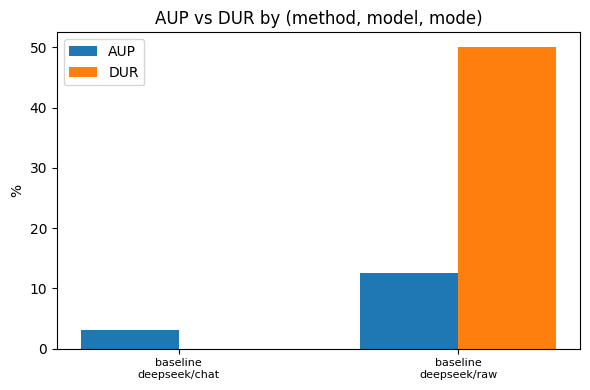

In [ ]:
import matplotlib.pyplot as plt

if disk_summaries:
    configs = list(disk_summaries.keys())
    labels = [f"{me}\n{m}/{mo}" for me, m, mo in configs]
    aup_vals = [(disk_summaries[k]["All"]["AUP"] or 0) * 100 for k in configs]
    dur_vals = [(disk_summaries[k]["All"]["DUR"] or 0) * 100 for k in configs]

    x = range(len(configs))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(6, len(configs) * 1.6), 4))
    ax.bar([i - width / 2 for i in x], aup_vals, width, label="AUP")
    ax.bar([i + width / 2 for i in x], dur_vals, width, label="DUR")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("%")
    ax.set_title("AUP vs DUR by (method, model, mode)")
    ax.legend()
    plt.tight_layout()
    plt.show()


### 14.4 Insights

In [ ]:
if disk_summaries:
    print("=== Insights ===")
    by_dur = sorted(
        ((k, s["All"]["DUR"]) for k, s in disk_summaries.items() if s["All"]["DUR"] is not None),
        key=lambda kv: kv[1],
    )
    if by_dur:
        best, worst = by_dur[0], by_dur[-1]
        print(f"Lowest DUR (best):  {best[0]} at {_pct(best[1])}")
        print(f"Highest DUR (worst): {worst[0]} at {_pct(worst[1])}")

    by_aup = sorted(
        ((k, s["All"]["AUP"]) for k, s in disk_summaries.items() if s["All"]["AUP"] is not None),
        key=lambda kv: kv[1], reverse=True,
    )
    if by_aup:
        print(f"Highest AUP: {by_aup[0][0]} at {_pct(by_aup[0][1])}")

    # Every non-baseline method vs baseline, for the same (model, mode).
    for (method_name, model_name, mode), s in disk_summaries.items():
        if method_name == "baseline":
            continue
        base_key = ("baseline", model_name, mode)
        if base_key not in disk_summaries:
            continue
        base_s = disk_summaries[base_key]
        if s["All"]["DUR"] is not None and base_s["All"]["DUR"] is not None:
            delta = (base_s["All"]["DUR"] - s["All"]["DUR"]) * 100
            direction = "reduces" if delta > 0 else "increases"
            print(f"{method_name} vs baseline ({model_name}/{mode}): DUR {direction} by "
                  f"{abs(delta):.1f} points ({_pct(s['All']['DUR'])} vs {_pct(base_s['All']['DUR'])})")
else:
    print("nothing to compare yet.")


=== Insights ===
Lowest DUR (best):  ('baseline', 'deepseek', 'chat') at 0.0%
Highest DUR (worst): ('baseline', 'deepseek', 'raw') at 50.0%
Highest AUP: ('baseline', 'deepseek', 'raw') at 12.5%
